In [1]:
%%capture
%cd ../
import os
os.environ["PYTHONHASHSEED"] = "42"
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Load environment variables from config.env in the repository root
repo_root = Path().resolve().parents[1]  # Navigate up from notebooks -> training -> src to repo root
load_dotenv(repo_root / 'config.env')

# === Select data version here ===
DATA_VERSION = "v2"  # Change to "v2", "v3", etc. as needed
# =================================

TRAINING_DATA_PATH = os.environ.get(f'TRAINING_DATA_{DATA_VERSION.upper()}')
if not TRAINING_DATA_PATH:
    raise ValueError(f'TRAINING_DATA_{DATA_VERSION.upper()} not set. Check config.env.')

In [3]:
import logging

import pandas as pd
from datetime import datetime

from ml_common.summary import get_label_distribution
from ml_common.util import load_pickle, save_pickle

from acu.evaluation import evaluate_valid, evaluate_test, predict, compute_threshold
from acu.pipeline import PrepACUData, feature_summary
from acu.training import set_seed, train_models, tune_params

set_seed()

pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 100)

logging.basicConfig(
    level=logging.INFO, 
    format='%(levelname)s:%(message)s', 
)

In [4]:
df = pd.read_parquet(TRAINING_DATA_PATH)
if "target_ED_date" not in df.columns:
    dates_path = Path(TRAINING_DATA_PATH).parent / "clinic_centered_dates.parquet"
    dates_df = pd.read_parquet(dates_path)
    df = df.merge(dates_df[["mrn", "assessment_date", "target_ED_date", "treatment_date"]],
                  on=["mrn", "assessment_date"], how="left")

In [5]:
prep = PrepACUData()
df = prep.preprocess(df, start_date="2006-01-01", end_date="2024-09-03")

06:43:23 INFO:Removing 22716 patients and 148507 sessions not from GI department
06:43:23 INFO:Removing 13 patients and 265 sessions before 2006-01-01 and after 2024-09-03
06:43:23 INFO:Removing 16 patients and 110 sessions in which patient had an ED visit on or before their treatment date.
06:43:23 INFO:Removing 0 patients and 12 sessions not first of a given week
06:43:23 INFO:Dropping the following 0 features for missingness over 80%: []
06:43:24 INFO:Removing 0 patients and 0 sessions with at least 80 percent of features missing
06:43:24 INFO:Reassigning the following 14 indicators with less than 6 patients as other: ['cancer_site_C02', 'cancer_site_C06', 'cancer_site_C07', 'cancer_site_C09', 'cancer_site_C12', 'cancer_site_C31', 'cancer_site_C37', 'cancer_site_C47', 'cancer_site_C48', 'cancer_site_C51', 'cancer_site_C53', 'cancer_site_C60', 'cancer_site_C65', 'cancer_site_C76']
06:43:24 INFO:No rare categories for morphology was found


In [6]:
# need to specify train test split date
X, Y, metainfo = prep.prepare('2021-12-31', df, n_folds=5) # n_folds=3
df = df.loc[X.index]

06:43:24 INFO:Removing 0 patients and 1778 sessions that occured after 2021-12-31 in the development cohort
06:43:24 INFO:One-hot encoding training data
06:43:24 INFO:Reassigning the following 15 indicators with less than 6 patients as other: ['regimen_GI OP FOLFOX + Nivolumab', 'regimen_GI OP FOLFOX + Pembolizumab', 'regimen_GI Pembrolizumab Q3W', 'regimen_GI Raltitrexed', 'regimen_GI-AVEX', 'regimen_GI-CISCAP+TRASLOAD(BS)', 'regimen_GI-DOCEQ3W', 'regimen_GI-EOX', 'regimen_GI-FOLFOX+PANITUMUMAB', 'regimen_GI-GEM+OXALI (BILIARY)', 'regimen_GI-GEM7WEEK+ERLOTINIB', 'regimen_GI-GEMFU (BILIARY)', 'regimen_GI-IRINOCISP', 'regimen_GI-OXALI', 'regimen_GI-XELOX+BEVACIZUMAB']
06:43:24 INFO:No rare categories for intent was found
06:43:24 INFO:One-hot encoding testing data
06:43:24 INFO:Reassigning the following regimen indicator columns that did not exist in train set as other:
regimen_GI Cetuximab + Encorafenib                                  14
regimen_GI Durvalumab                          

In [7]:
# reset X, Y, metainfo, df indices
X = X.reset_index(drop=True)
Y = Y.reset_index(drop=True)
metainfo = metainfo.reset_index(drop=True)
df = df.reset_index(drop=True)

# split into train and test
train_mask, test_mask = metainfo['split'] == 'Train', metainfo['split'] == 'Test'
X_train, X_test = X[train_mask], X[test_mask]
Y_train, Y_test = Y[train_mask], Y[test_mask]
metainfo_train, metainfo_test = metainfo[train_mask], metainfo[test_mask]
df_train, df_test = df[train_mask], df[test_mask]

In [8]:
# make sure there is no patient leakage
set(metainfo_train['mrn'].unique()) & set(metainfo_test['mrn'].unique())

set()

In [9]:
count = pd.DataFrame({
    'Number of sessions': metainfo.groupby('split').apply(len, include_groups=False), 
    'Number of patients': metainfo.groupby('split')['mrn'].nunique()}
).T
count['Total'] = count.sum(axis=1)
print(f'\n{count.to_string()}')


split               Test  Train  Total
Number of sessions  3945  22933  26878
Number of patients   744   4453   5197


In [10]:
mask = X['cycle_number'] == X_train['cycle_number'].min()
count = pd.DataFrame({
    'Number of sessions': metainfo[mask].groupby('split').apply(len, include_groups=False), 
    'Number of patients': metainfo[mask].groupby('split')['mrn'].nunique()}
).T
count['Total'] = count.sum(axis=1)
print(f'\n{count.to_string()}')


split               Test  Train  Total
Number of sessions   698   4068   4766
Number of patients   529   3218   3747


In [11]:
# Feature Characteristics
x = prep.ohe.encode(df.loc[X_train.index].copy(), verbose=False) # get original (non-normalized, non-imputed) data one-hot encoded
x = x[[col for col in x.columns if not (col in metainfo.columns or col.startswith('target'))]]
feature_summary(x, save_path=f'./deployment/feature_summary_ED_clinic_anchored.csv').sample(10, random_state=42)

,Features,Group,Mean (SD),Missingness (%)
63,"Topography ICD-0-3 C50, Breast",Cancer,0.002 (0.042),0.0
18,Magnesium (mmol/L),Laboratory,0.806 (0.103),13.1
20,Mean Corpuscular Hemoglobin Concentration (g/L),Laboratory,330.761 (12.838),7.6
96,Regimen GI-FU CIV + RT,Treatment,0.006 (0.078),0.0
49,"Topography ICD-0-3 C16, Stomach",Cancer,0.095 (0.293),0.0
13,Creatinine (umol/L),Laboratory,74.720 (49.632),11.0
46,Days Since Last Treatment,Treatment,24.701 (103.379),0.0
114,Regimen GI-RAMUCIRUMAB+PACLI,Treatment,0.010 (0.098),0.0
2,Height (cm),Demographic,167.503 (9.823),0.0
28,Prothrombin Time International Normalized Ratio,Laboratory,1.101 (0.278),76.2


# Model Training

In [11]:
# LGBM does not like non alphanumeric characters (except for _)
for char in ['(', ')', '+', '-', '/', ',']: 
    X_train.columns = X_train.columns.str.replace(char, '_')
    X_test.columns = X_test.columns.str.replace(char, '_')
    X.columns = X.columns.str.replace(char, '_')

In [13]:
%%capture
# Hyperparameter tuning
# TODO: try greater kappa for greater exploration
algs = ['LASSO', 'RF', 'Ridge', 'XGB', 'LGBM']
best_params = {}
for alg in algs:
    best_params[alg] = tune_params(alg, X_train, Y_train, metainfo_train, log_dir='./deployment/logs/bayes_opt')
os.makedirs('./deployment/models', exist_ok=True)
save_pickle(best_params, './deployment/models', f'best_params_clinic_anchored')

In [12]:
best_params = load_pickle('./deployment/models', f'best_params_clinic_anchored')
models = train_models(X_train, Y_train, metainfo_train, best_params) # NOTE: Number of CV folds = 3

/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is depreca

## Model Selection
Select final model based on the average performance across the validation folds

In [13]:
evaluate_valid(models, X_train, Y_train, metainfo_train)

Ridge              LASSO                XGB                LGBM  \
           AUPRC     AUROC    AUPRC     AUROC    AUPRC     AUROC     AUPRC   
ED_30d  0.222674  0.784453  0.22128  0.784071  0.68017  0.960009  0.195334   

                        RF            
           AUROC     AUPRC     AUROC  
ED_30d  0.778049  0.324083  0.818655

## Evaluate Model

In [20]:
pd.concat([evaluate_test(model, X_test, Y_test) for alg, model in models.items()], keys=models.keys()).T

Ridge                                       LASSO  \
           AUPRC                    AUROC    Brier     AUPRC   
ED_30d  0.197176  0.6765 (0.6414, 0.7071)  0.07617  0.204028   

                                                XGB                           \
                          AUROC     Brier     AUPRC                    AUROC   
ED_30d  0.6812 (0.6464, 0.7120)  0.075876  0.200272  0.6917 (0.6612, 0.7199)   

                      LGBM                                          RF  \
           Brier     AUPRC                    AUROC     Brier    AUPRC   
ED_30d  0.075807  0.186103  0.6950 (0.6655, 0.7245)  0.076124  0.22523   

                                           
                          AUROC     Brier  
ED_30d  0.7111 (0.6815, 0.7400)  0.074242

In [25]:
# first cycle only
mask = X_test['cycle_number'] == X_train['cycle_number'].min()
pd.concat([evaluate_test(model, X_test[mask], Y_test[mask]) for alg, model in models.items()], keys=models.keys()).T

Ridge                                        LASSO  \
           AUPRC                    AUROC     Brier     AUPRC   
ED_30d  0.342472  0.7030 (0.6435, 0.7572)  0.127017  0.346493   

                                                XGB                           \
                          AUROC     Brier     AUPRC                    AUROC   
ED_30d  0.7065 (0.6490, 0.7608)  0.126334  0.342652  0.7098 (0.6590, 0.7557)   

                      LGBM                                           RF  \
           Brier     AUPRC                    AUROC     Brier     AUPRC   
ED_30d  0.126743  0.271937  0.6808 (0.6238, 0.7364)  0.130662  0.352651   

                                           
                          AUROC     Brier  
ED_30d  0.7305 (0.6786, 0.7785)  0.121675

In [18]:
chosen_model = 'RF'
model = models[f'{chosen_model}']
save_pickle(model['ED_30d'], './deployment/models', f'{chosen_model}_ED_visit_clinic_anchored')
X.to_parquet(f'./deployment/models/X_clinic_anchored.parquet.gzip')
Y.to_parquet(f'./deployment/models/Y_clinic_anchored.parquet.gzip')
save_pickle(prep, './deployment', f'prep_ED_visit_clinic_anchored')

In [20]:
# save imputation constants 
import yaml
import numpy as np

def _patient_median(df_sex: pd.DataFrame, col: str) -> float:
    """Average the value within each patient, then take the median across patients."""
    return float(df_sex.groupby("mrn")[col].mean().median())

female_mask = df_train["female"] == True
male_mask = df_train["female"] == False

imputation_config = {
    "chemo_data_imputation": {
        "height": {
            "female_true": _patient_median(df_train[female_mask], "height"),
            "female_false": _patient_median(df_train[male_mask], "height"),
        },
        "weight": {
            "female_true": _patient_median(df_train[female_mask], "weight"),
            "female_false": _patient_median(df_train[male_mask], "weight"),
        },
        "line_of_therapy": int(np.rint(df_train["line_of_therapy"].mean())),
        "cycle_number": 1,
        "source": DATA_VERSION,
        "notes": "imputation values from training cohort",
    }
}

output_yaml = repo_root / "src" / "data_prep" / "imputation_constants.yaml"
with open(output_yaml, "w") as f:
    yaml.dump(imputation_config, f, sort_keys=False, default_flow_style=False)

# Plot SHAP

In [23]:
import shap

def predict_ensemble(data):
    return np.mean([m.predict_proba(data)[:, 1] for m in model['ED_30d']], axis=0)

rng = np.random.default_rng(42)
# restrict to first cycle patients only
mask = X_test['cycle_number'] == X_train['cycle_number'].min()
X_test_model = X_test[mask]
X_shap_bg = X_test_model.sample(50, random_state=42)   # background reference
X_shap = X_test_model# .sample(100, random_state=42)     # rows to explain

explainer = shap.KernelExplainer(predict_ensemble, X_shap_bg)
shap_values = explainer.shap_values(X_shap, nsamples=100)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)

/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid

  0%|          | 0/698 [00:00<?, ?it/s]

/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wayne/miniconda3/envs/model_deployer/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid

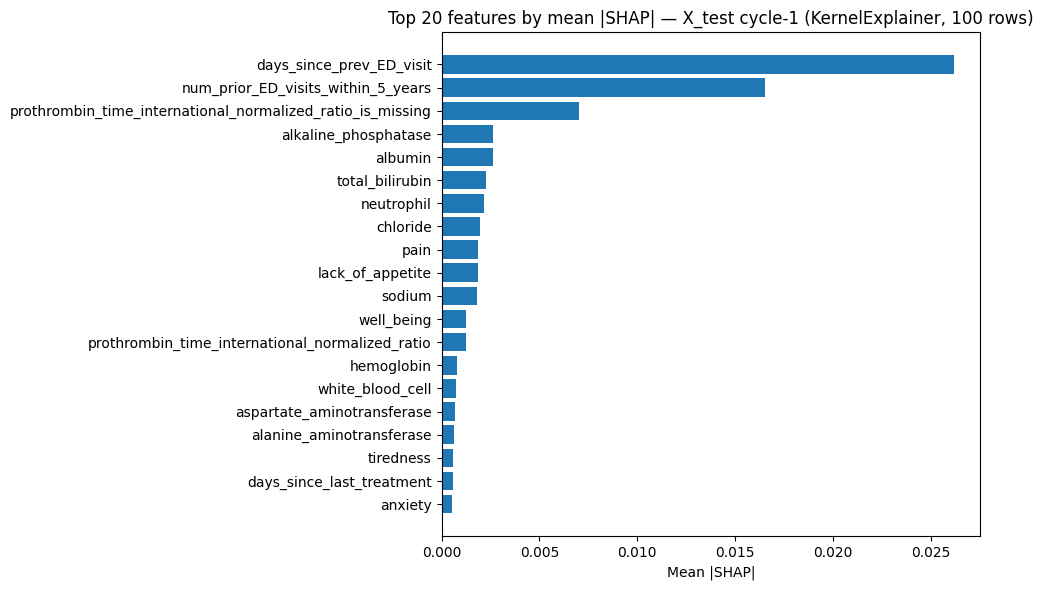

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
top = importance.head(20)
ax.barh(top.index[::-1], top.values[::-1])
ax.set_xlabel("Mean |SHAP|")
ax.set_title("Top 20 features by mean |SHAP| — X_test cycle-1 (KernelExplainer, 100 rows)")
plt.tight_layout()
plt.show()

In [26]:
metainfo_train['assessment_date'].max()

Timestamp('2021-12-31 00:00:00')

In [27]:
metainfo_test['assessment_date'].min()

Timestamp('2022-01-04 00:00:00')

In [32]:
import numpy as np
models = load_pickle(str(repo_root / "Models"), "A2R_v2_RF_ED_visit_clinic_anchored")
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
def predict(models, data):
    # average across the folds
    return np.mean([m.predict_proba(data)[:, 1] for m in models], axis=0)
def _bootstrap_auc_ci(y_true, y_pred, n_samples=1000, seed=42, sample_size=319, replace=False):
    """Compute 95% CI for AUROC via bootstrap resampling."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    y_true = np.asarray(y_true)
    idxs = np.arange(n)
    aucs = []
    for _ in range(n_samples):
        idx = rng.choice(idxs, size=sample_size, replace=replace)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_pred[idx]))
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    return lo, hi
mask = X_test['cycle_number'] == X_train['cycle_number'].min()
pred_values = predict(models, X_test[mask])
bootstrap_auc_ci = _bootstrap_auc_ci(Y_test['ED_30d'][mask], pred_values, n_samples=1000, seed=42, sample_size=319, replace=False)